# Implementing the Concept of Persistence in a workflow using InMemorySaver() and checkpointer

Persistence in LangGraph:

Core Idea:
LangGraph is stateless by default — every run starts fresh. Persistence means saving graph state across runs, turns, or interruptions.To solve this, we use and implement the concept of Persistence in LangGraph.
The backbone of LangGraph persistence is the checkpointer. It saves a state snapshot after every node execution.
We can understand this using the following example:




In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image

In [3]:
# Load the environment variables from the .env file
load_dotenv()

# model : 
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.3)

In [4]:
# State definition:
class WorkflowState(TypedDict):
    topic : str
    joke : str
    explanation : str


In [11]:
# Node Functions : 

def generate_joke(state: WorkflowState) -> WorkflowState:
    prompt = f"Generate a joke about {state['topic']}."
    joke = llm.invoke(prompt).content
    state['joke'] = joke
    return state

def explain_joke(state: WorkflowState) -> WorkflowState:
    prompt = f"Explain the joke: {state['joke']}."
    explanation = llm.invoke(prompt).content
    state['explanation'] = explanation
    return state

In [7]:
# initialize the graph

graph = StateGraph(WorkflowState)

graph.add_node("Generate_Joke", generate_joke)
graph.add_node("Explain_Joke", explain_joke)

# Defining the edges
graph.add_edge(START, "Generate_Joke")
graph.add_edge("Generate_Joke", "Explain_Joke")
graph.add_edge("Explain_Joke", END)

# Initialize the in-memory saver
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [12]:
# Config with thread id 
config1 = {"configurable": {"thread_id": "1"}}

# Executing the workflow with an initial state
Result = workflow.invoke({"topic": "programming"}, config=config1)

# Display the final result
print("Final Result:", Result)


Final Result: {'topic': 'programming', 'joke': AIMessage(content='Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 41, 'total_tokens': 54, 'completion_time': 0.030296639, 'completion_tokens_details': None, 'prompt_time': 0.002462431, 'prompt_tokens_details': None, 'queue_time': 0.319239817, 'total_time': 0.03275907}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e444e-dee4-7c72-8b3d-e993896b9a6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 13, 'total_tokens': 54}), 'explanation': AIMessage(content='The joke is: "Why do programmers prefer dark mode? Because light attracts bugs."\n\nThis joke is a play on words. In programming, a "bug" refers to an error or a flaw in the cod

In [ ]:
# Displaying the saved in memory snapshot for the given config
workflow.get_state(config1)

StateSnapshot(values={'topic': 'programming', 'joke': AIMessage(content='Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 41, 'total_tokens': 54, 'completion_time': 0.030296639, 'completion_tokens_details': None, 'prompt_time': 0.002462431, 'prompt_tokens_details': None, 'queue_time': 0.319239817, 'total_time': 0.03275907}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e444e-dee4-7c72-8b3d-e993896b9a6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 13, 'total_tokens': 54}), 'explanation': AIMessage(content='The joke is: "Why do programmers prefer dark mode? Because light attracts bugs."\n\nThis joke is a play on words. In programming, a "bug" refers to an error or a flaw in 

In [15]:
# History of Snapshot :
list(workflow.get_state_history(config1)) 

[StateSnapshot(values={'topic': 'programming', 'joke': AIMessage(content='Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 41, 'total_tokens': 54, 'completion_time': 0.030296639, 'completion_tokens_details': None, 'prompt_time': 0.002462431, 'prompt_tokens_details': None, 'queue_time': 0.319239817, 'total_time': 0.03275907}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e444e-dee4-7c72-8b3d-e993896b9a6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 13, 'total_tokens': 54}), 'explanation': AIMessage(content='The joke is: "Why do programmers prefer dark mode? Because light attracts bugs."\n\nThis joke is a play on words. In programming, a "bug" refers to an error or a flaw in

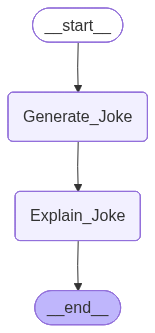

In [16]:
# Visualize the graph
Image(workflow.get_graph().draw_mermaid_png())

# Time Travel Concept using CheckPoint Id


In [18]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id" : "1f1541e4-28c3-6243-bfff-fe3c46b2697f"}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1541e4-28c3-6243-bfff-fe3c46b2697f'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-05-20T07:33:56.743225+00:00', parent_config=None, tasks=(PregelTask(id='bfeb594b-1637-3e1e-6c4b-d7efd6a42fd9', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'programming'}),), interrupts=())